# Bắt đầu

## Đề bài:  
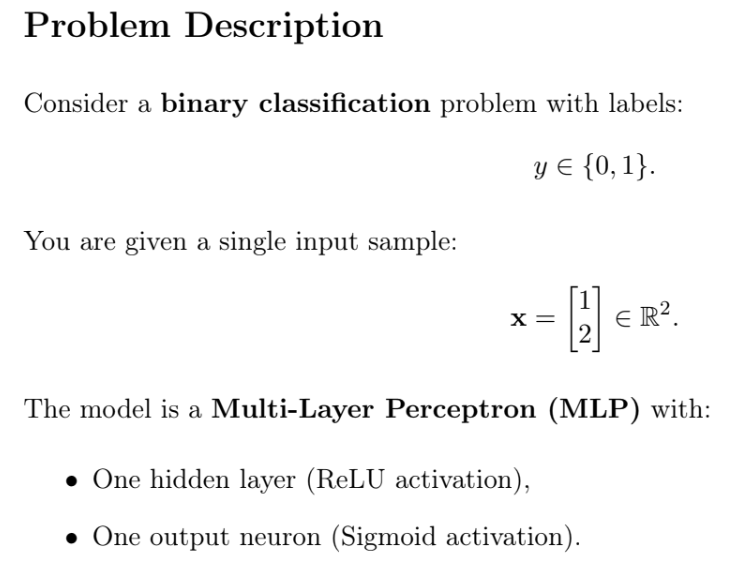  
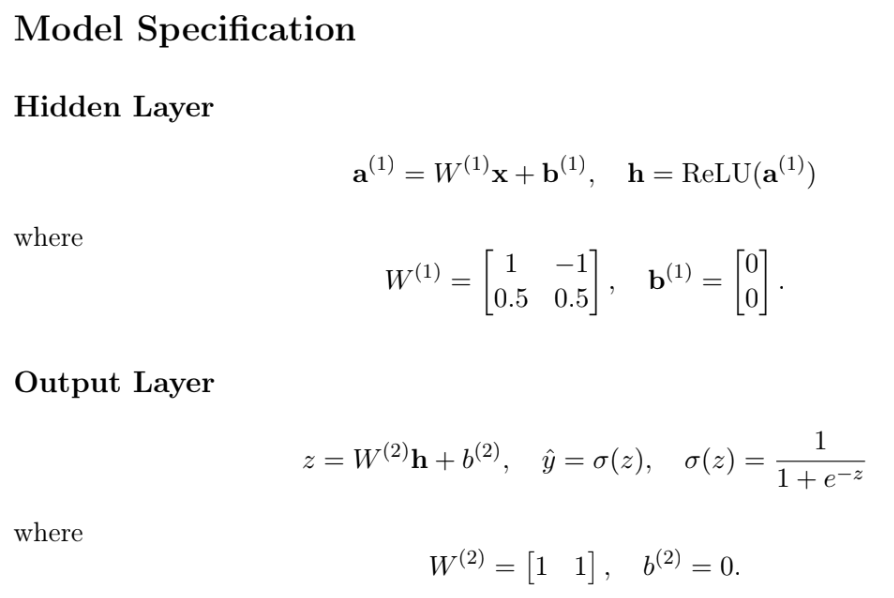  
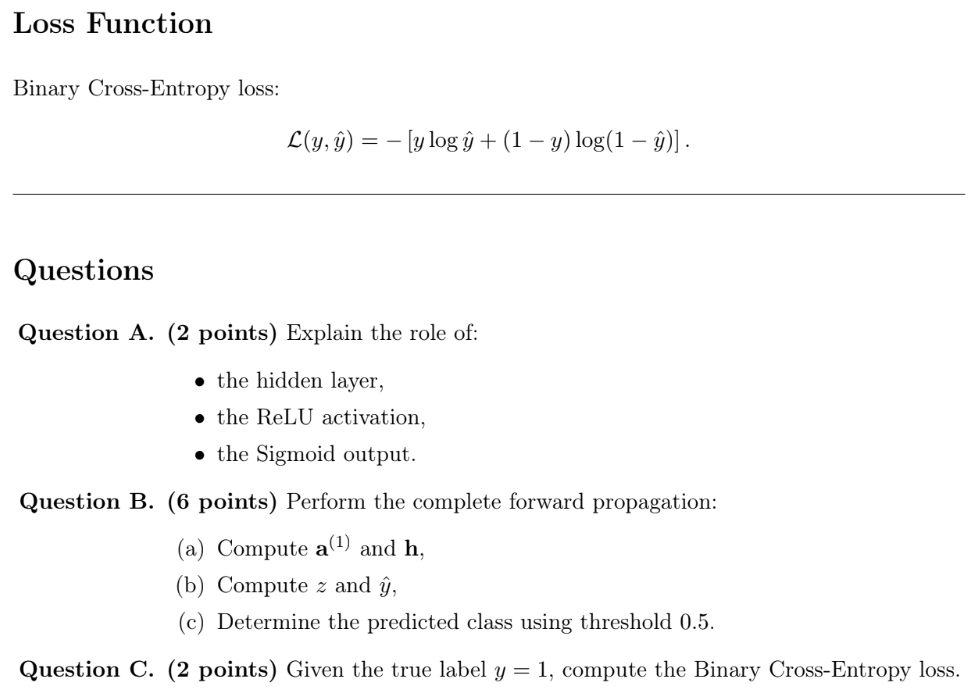  

## Bài giải:  

### <span style="color: blue"> Câu A: Giải thích vai trò</span>    
* Hidden Layer (lớp ẩn):  
    Lớp ẩn biến đổi input x từ không gian 2 chiều sang không gian mới, giúp mô hình học được các đặc trưng phức tạp mà input thô không thể hiện trực tiếp. 
Không có lớp ẩn, MLP chỉ là hồi quy tuyến tính đơn giản.  

* ReLU Activation:  $$\text{ReLU}(x) = \max(0,x)$$  

Vai trò: đưa vào phi tuyến tính — những giá trị âm bị triệt tiêu về 0, giá trị dương giữ nguyên. Nếu không có hàm kích hoạt, nhiều lớp chồng nhau vẫn chỉ là một phép biến đổi tuyến tính.  

* Sigmoid Output:  $$\sigma(z)=\frac{1}{1+e^{-z}}$$  

Vai trò: ép output về khoảng (0,1) để diễn giải như xác suất → phù hợp bài toán phân loại nhị phân.  

###  <span style="color: blue"> Câu B: Forward propagation </span>   

* <span style="color: green">**Tìm $\mathbf{a}^{(1)}$ và h** </span> 

Từ đề bài ta có:  
  
$\mathbf{x} = \begin{bmatrix} 1 \\ 2 \end{bmatrix} \in \mathbb{R}^2 \quad$  ;  $\quad\mathbf{W}^{(1)} = \begin{bmatrix} 1 & -1 \\ 0.5 & 0.5 \end{bmatrix} \quad$  ;  $\quad \mathbf{b}^{(1)} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$  

* <span style="color: orange"><u><i>Tìm a:</i></u></span>  

$\mathbf{a}^{(1)} = \mathbf{W}^{(1)} \cdot x + \mathbf{b}^{(1)}$  

$\mathbf{a}^{(1)} =  \begin{bmatrix} 1 & -1 \\ 0.5 & 0.5 \end{bmatrix} \begin{bmatrix} 1 \\ 2 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \end{bmatrix} = \begin{bmatrix} -1 \\ 1.5 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \end{bmatrix} =  \begin{bmatrix} -1 \\ 1.5 \end{bmatrix}$  

* <span style="color: orange"><u><i>Tìm h:</i></u></span>  

h = $\text{ReLU}(\mathbf{a}^{(1)}) =  \begin{bmatrix}  \max(-1, 0) \\ \max(0, 1.5) \end{bmatrix} = \begin{bmatrix} 0 \\ 1.5 \end{bmatrix}$    

* <span style="color: green">**Tìm z và $\hat{y}$**</span>  

Ta có:  

$\mathbf{W}^{(2)} = \begin{bmatrix} 1 & 1  \end{bmatrix}\quad$ ; $\mathbf{b}^{(2)} = 0\quad$ ; $\quad$ h = $\begin{bmatrix} 0 \\ 1.5 \end{bmatrix}\quad$   

* <span style="color: orange"><u><i> Tìm z:</i></u></span> 

z = $\mathbf{W}^{(2)} \cdot h + \mathbf{b}^{(2)}\quad$ = \begin{bmatrix} 1 & 1 \end{bmatrix} \begin{bmatrix} 0 \\ 1.5 \end{bmatrix} + 0 = 1.5 + 0 = 1.5  

* <span style="color: orange"><u><i>Tìm $\hat{y}$</i></u></span>  

$\hat{y}$ = $\sigma(z)\quad$  mà $\quad\sigma(z) = \frac{1}{1+e^{-z}}$  

=> $\hat{y} = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-1.5}} = 0.8176$

* <span style="color: green"> **Xác định lớp dự đoán bằng cách sử dụng ngưỡng 0.5**</span>  

Ta có:  

$y \in $ {0,1}  
ngưỡng 0.5    
=> $\hat{y}$ = 0.8176 > 0.5 ==> dự đoán lớp y = 1  

In [2]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 38.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 30.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 36.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 35.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


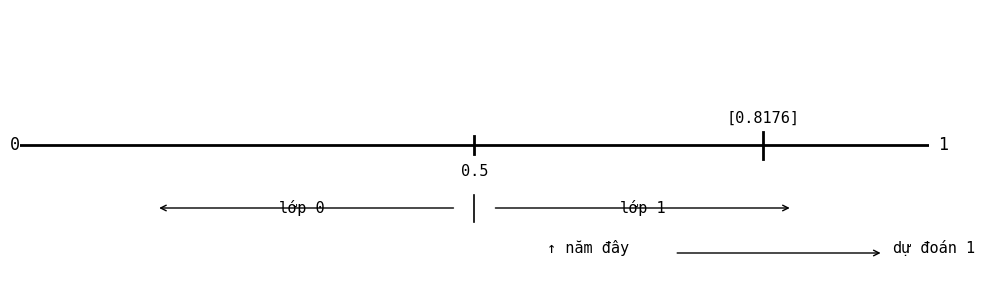

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
ax.axis("off")

# --- Đường thẳng chính ---
ax.plot([0, 1], [0, 0], color="black", linewidth=2)

# --- Dấu | ở 0.5 ---
ax.plot([0.5, 0.5], [-0.1, 0.1], color="black", linewidth=2)

# --- Điểm [0.8176] ---
threshold = 0.8176
ax.plot([threshold, threshold], [-0.15, 0.15], color="black", linewidth=2)
ax.text(threshold, 0.25, f"[{threshold}]", ha="center", fontsize=11, fontfamily="monospace")

# --- Nhãn 0 và 1 ---
ax.text(0.0,  0.0, "0", ha="right", va="center", fontsize=12, fontfamily="monospace")
ax.text(1.01, 0.0, "1", ha="left",  va="center", fontsize=12, fontfamily="monospace")

# --- Nhãn 0.5 ---
ax.text(0.5, -0.35, "0.5", ha="center", fontsize=11, fontfamily="monospace")

# --- Mũi tên và nhãn lớp ---
ax.annotate("", xy=(0.48, -0.7), xytext=(0.15, -0.7),
            arrowprops=dict(arrowstyle="<-", color="black"))
ax.text(0.31, -0.7, "lớp 0", ha="center", va="center", fontsize=11, fontfamily="monospace")

ax.annotate("", xy=(0.85, -0.7), xytext=(0.52, -0.7),
            arrowprops=dict(arrowstyle="->", color="black"))
ax.text(0.685, -0.7, "lớp 1", ha="center", va="center", fontsize=11, fontfamily="monospace")

ax.plot([0.5, 0.5], [-0.55, -0.85], color="black", linewidth=1.2)

# --- Chú thích bên dưới ---
ax.annotate("", xy=(0.95, -1.2), xytext=(0.72, -1.2),
            arrowprops=dict(arrowstyle="->", color="black"))
ax.text(0.67, -1.2, "↑ năm đây", ha="right", fontsize=11, fontfamily="monospace")
ax.text(0.96, -1.2, "dự đoán 1", ha="left",  fontsize=11, fontfamily="monospace")

plt.tight_layout()
plt.show()

### <span style="color: blue"> Câu C: Binary Cross-Entropy loss </span>  

$\mathcal{L}(y,\hat{y}) = -\left[y\log \hat{y} + (1 - y)log(1 - \hat{y})\right]$  
                        = - $\left[1\log 0.8176 + (1 - 1)log(1 - 0.8176)\right]$ = - $log(0.8176)$ = 0.2014                      
                        




# Kết thúc